## Add feature *size_kw* to model (cost ~ days, size)

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

In [2]:
# Import sklearn stuff

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
# read cleaned data
dfModelAll = pd.read_csv('../local/data/LBNL_openpv_tts_data/ModelAll.csv', index_col='row', dtype={'state':'category'})

In [4]:
dfModelAll.head()

,num_days,size_kw,state,cost_per_watt,scaleSize
row,,,,,
0,0.0,2.2824,CA,10.734315,0
1,21.0,1.8504,CA,11.108701,0
2,26.0,2.3076,CA,8.667013,0
3,84.0,2.3316,CA,13.270286,0
4,111.0,0.9300,CA,14.654839,0


In [6]:
dfModelAll.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 364212 entries, 0 to 364211
Data columns (total 5 columns):
num_days         364212 non-null float64
size_kw          364212 non-null float64
state            364212 non-null category
cost_per_watt    364212 non-null float64
scaleSize        364212 non-null int64
dtypes: category(1), float64(3), int64(1)
memory usage: 14.2 MB


In [7]:
dfModelAll.state.unique()

[CA, OR, AZ, NY, MN, ..., MD, CT, FL, NM, AR]
Length: 19
Categories (19, object): [CA, OR, AZ, NY, ..., CT, FL, NM, AR]

#####  There is a  choice to deal with encoding of categorical variable 'state' with pandas or in the pipeline.  I don't want to make polynomial terms for the state.  For now, we defer to next step.

In [8]:
dfModelAll.get_dtype_counts()

category    1
float64     3
int64       1
dtype: int64

### Make a reduced model by sampling.

In [9]:
dfMod = dfModelAll.sample(frac=0.3)

In [10]:
len(dfModelAll), len(dfMod)

(364212, 109264)

### Set up a sklearn pipeline

In [11]:
# set up to model two features, num_days, size_kw
X = dfMod[['num_days', 'size_kw']].values
y = dfMod[['cost_per_watt']].values
X.shape, y.shape

((109264, 2), (109264, 1))

###  check summary stats for cost

In [12]:
np.std(dfModelAll.cost_per_watt)

2.1487016159206926

In [13]:
np.mean(dfModelAll.cost_per_watt)

5.477365160843267

In [14]:
np.median(dfModelAll.cost_per_watt)

4.920527472527473

### Make a pipeline with the appropriate steps

In [11]:
# Setup the pipeline steps: steps
steps = [('scaler', StandardScaler()),
         ('poly', PolynomialFeatures()),
         ('LR', LinearRegression())]

# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

In [12]:
# what's in the pipeline?
pipeline.get_params().keys()

dict_keys(['memory', 'steps', 'scaler', 'poly', 'LR', 'scaler__copy', 'scaler__with_mean', 'scaler__with_std', 'poly__degree', 'poly__include_bias', 'poly__interaction_only', 'LR__copy_X', 'LR__fit_intercept', 'LR__n_jobs', 'LR__normalize'])

### Search for best polynomial degree

In [13]:
# Specify the hyperparameter space.
# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 4)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=None)

# Create the GridSearchCV object: gm_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, return_train_score=True)

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(r2))

Best parameters: {'poly__degree': 3}
test R squared: 0.47619470072551945


In [14]:
# this will show the results data structure
# gs_cv.cv_results_

#### The pipeline above is working.  Next step is to add a scorer that produces multiple scores.  Example below.

#### instead of defining your own scorer to track multiple metrics, you can hand gridsearchcv a list of scoring fns to use (but you can only use the ones sklearn blesses).  the other way is to pass a dictionary...

In [15]:
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Specify the hyperparameter space; .
# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 11)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=None)

# Create the GridSearchCV object: gs_cv
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

gs_cv = GridSearchCV(pipeline, param_grid, cv=3, 
                     scoring=scoring, return_train_score=True,
                     refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(r2))

# uncomment to see results ds
# gs_cv.cv_results_

Best parameters: {'poly__degree': 10}
Best R squared: 0.5059603707308636


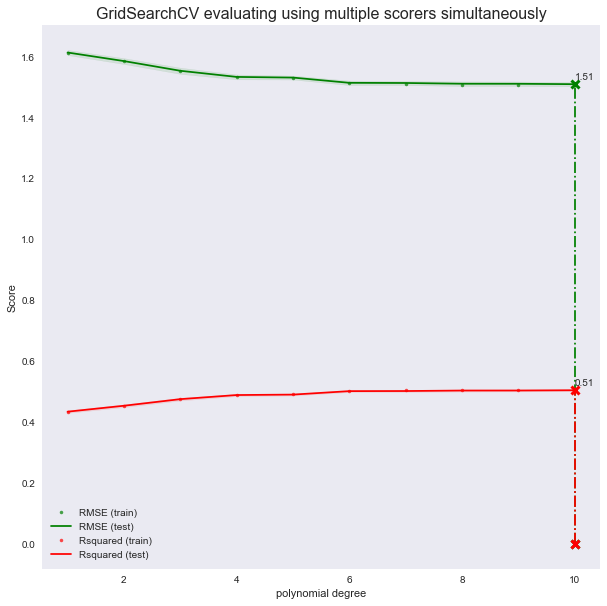

In [16]:
results = gs_cv.cv_results_

fig, ax = plt.subplots(figsize=(10, 10))
plt.title("GridSearchCV evaluating using multiple scorers simultaneously", fontsize=16)

plt.xlabel("polynomial degree")
plt.ylabel("Score")

# I think Seaborn ignores this...
plt.grid(True)

###            two__underscores
X_axis = np.array(results['param_poly__degree'].data, dtype=float)

for scorer, color in zip(sorted(scoring), ['g', 'r']):
    for sample, style in (('train', '.'), ('test', '-')):
        sample_score_mean = np.abs(results['mean_%s_%s' % (sample, scorer)])
        sample_score_std = results['std_%s_%s' % (sample, scorer)]
        ax.fill_between(X_axis, sample_score_mean - sample_score_std,
                        sample_score_mean + sample_score_std,
                        alpha=0.1 if sample == 'test' else 0, color=color)
        ax.plot(X_axis, sample_score_mean, style, color=color,
                alpha=1 if sample == 'test' else 0.7,
                label="%s (%s)" % (scorer, sample))

    best_index = np.abs(np.nonzero(results['rank_test_%s' % scorer] == 1)[0][0])
    best_score = np.abs(results['mean_test_%s' % scorer][best_index])

    # Plot a dotted vertical line at the best score for that scorer marked by x
    ax.plot([X_axis[best_index], ] * 2, [0, best_score],
            linestyle='-.', color=color, marker='x', markeredgewidth=3, ms=8)

    # Annotate the best score for that scorer
    ax.annotate("%0.2f" % best_score,
                (X_axis[best_index], best_score + 0.015))

plt.legend(loc="best")
plt.grid(False)
plt.show();

In [17]:
list(zip(gs_cv.cv_results_['param_poly__degree'], 
         gs_cv.cv_results_['mean_test_Rsquared'], 
         np.abs(gs_cv.cv_results_['mean_test_RMSE'])))

[(1, 0.4350545937007787, 1.615207221460146),
 (2, 0.4545574105884229, 1.58708246490301),
 (3, 0.47626775192635074, 1.555180854180123),
 (4, 0.48976217130290434, 1.5350104271287146),
 (5, 0.491216359946263, 1.5328194231396377),
 (6, 0.5025911697712118, 1.5155917246616042),
 (7, 0.502940337334725, 1.5150590853383605),
 (8, 0.5045343753385352, 1.5126256529354558),
 (9, 0.5046482465005325, 1.5124549936558267),
 (10, 0.5055004035787429, 1.511151072166834)]

In [18]:
gs_cv.cv_results_

{'mean_fit_time': array([0.0117, 0.0207, 0.0274, 0.0468, 0.0779, 0.0996, 0.1327, 0.1862,
        0.237 , 0.2931]),
 'mean_score_time': array([0.0023, 0.0047, 0.007 , 0.0134, 0.0201, 0.0461, 0.0561, 0.0846,
        0.1076, 0.1387]),
 'mean_test_RMSE': array([-1.6152, -1.5871, -1.5552, -1.535 , -1.5328, -1.5156, -1.5151,
        -1.5126, -1.5125, -1.5112]),
 'mean_test_Rsquared': array([0.4351, 0.4546, 0.4763, 0.4898, 0.4912, 0.5026, 0.5029, 0.5045,
        0.5046, 0.5055]),
 'mean_train_RMSE': array([-1.6151, -1.5869, -1.5548, -1.534 , -1.5306, -1.5137, -1.5122,
        -1.509 , -1.5081, -1.507 ]),
 'mean_train_Rsquared': array([0.4352, 0.4547, 0.4765, 0.4905, 0.4927, 0.5039, 0.5048, 0.5069,
        0.5075, 0.5082]),
 'param_poly__degree': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'params': [{'poly__degree': 1},
  {'

### Plot curves for best fit model.

Best parameters: {'poly__degree': 6}
Best R squared: 0.5061135993683097


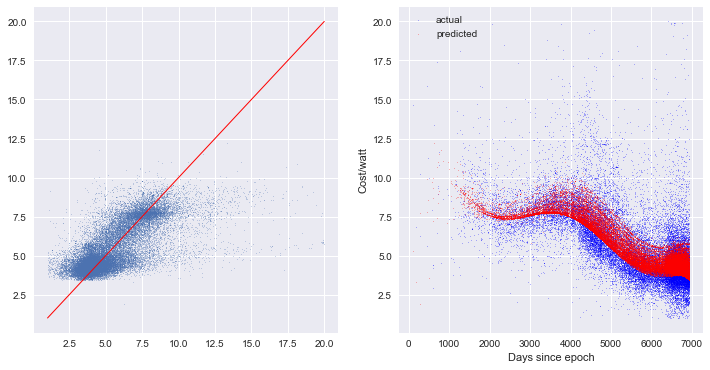

In [19]:
poly_space = np.arange(6, 7)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=None)

# Create the GridSearchCV object: gm_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, return_train_score=True)

# Fit to the training set
model = gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(r2))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(y_test, model.predict(X_test), marker='.', s=2, alpha=0.3);
ax1.plot(np.array([1,20]), np.array([1,20]), linewidth=1, color='red')
ax2.set_ylabel('predicted')
ax2.set_xlabel('actual')

ax2.scatter(X_test[:, 0], y_test, marker='.', color='blue', s=2, alpha=0.3, label='actual')
ax2.scatter(X_test[:, 0], model.predict(X_test), marker='.', color='red', s=2, alpha=0.3, label='predicted')
ax2.set_ylabel('Cost/watt')
ax2.set_xlabel('Days since epoch')
ax2.legend()

plt.show();